In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict , Literal , Annotated
from math import sqrt
from pydantic import BaseModel , Field
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import add_messages
from langgraph.checkpoint.memory import MemorySaver , InMemorySaver 
load_dotenv()

True

In [16]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [17]:
class LLMstate(TypedDict):
    message : Annotated[list[BaseMessage] , add_messages]

In [18]:
checkpointer = InMemorySaver()
graph = StateGraph(LLMstate)

In [19]:
def chat_node(state:LLMstate):
    message = state["message"]

    response = model.invoke(message)

    return {"message" : [response]}

In [20]:
graph.add_node("chat_node" , chat_node)

In [21]:
graph.add_edge(START , "chat_node")
graph.add_edge ("chat_node" , END)
workflow = graph.compile(checkpointer = checkpointer )

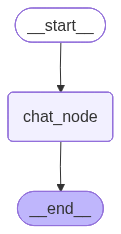

In [22]:
workflow

In [23]:
thread_id =  "69"

while True:
    user_input = input("user query: ")

    if user_input.strip().lower() in ["exit" , "quit" , "bye"]:
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    response = workflow.invoke({"message":[HumanMessage(content = user_input)  ]}, config = config)

    print("AI:" , response["message"][-1].content)

AI: Hello Karan! Nice to meet you. How can I assist you today?
AI: Your name is Karan Bhatia.


In [24]:
workflow.get_state(config=config)

StateSnapshot(values={'message': [HumanMessage(content='HI MY NAME IS KARAN BHATIA', additional_kwargs={}, response_metadata={}, id='91407366-189c-42d8-85b8-3c8e112e7caa'), AIMessage(content='Hello Karan! Nice to meet you. How can I assist you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f6187-875f-75f0-9451-6b2b3291c748-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 393, 'total_tokens': 403, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 378}}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='5e3d5215-38dd-4df7-b51b-f58f7f302b4a'), AIMessage(content='Your name is Karan Bhatia.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'},

In [29]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'message': [HumanMessage(content='HI MY NAME IS KARAN BHATIA', additional_kwargs={}, response_metadata={}, id='91407366-189c-42d8-85b8-3c8e112e7caa'), AIMessage(content='Hello Karan! Nice to meet you. How can I assist you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f6187-875f-75f0-9451-6b2b3291c748-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 393, 'total_tokens': 403, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 378}}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='5e3d5215-38dd-4df7-b51b-f58f7f302b4a'), AIMessage(content='Your name is Karan Bhatia.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}